# 01 - Exploratory Data Analysis (EDA)

Notebook phân tích dữ liệu gốc: kiểm tra kích thước, kiểu dữ liệu, missing values, thống kê mô tả, phân phối target, mất cân bằng lớp, tương quan và trực quan hóa các biến quan trọng.

## 1. Import thư viện

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load dữ liệu

In [3]:
DATA_PATH = ROOT / "data" / "raw" / "diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Kiểm tra thông tin tổng quan

In [4]:
# Kich thuoc du lieu
print(f"So dong: {df.shape[0]:,}")
print(f"So cot: {df.shape[1]}")
print(f"\nSo dong: 253,680")
print(f"So cot: 22 cot gom 1 target va 21 feature")

So dong: 253,680
So cot: 22

So dong: 253,680
So cot: 22 cot gom 1 target va 21 feature


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
df.dtypes

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

## 4. Kiểm tra missing values

In [7]:
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_report

,missing_count,missing_percent
Diabetes_binary,0,0.0
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0


In [8]:
# Ket luan: Dataset sach, khong co missing values
print("Ket luan: Dataset sach, khong can xu ly missing values.")

Ket luan: Dataset sach, khong can xu ly missing values.


## 5. Thống kê mô tả

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [10]:
# Chu y cac bien lien tuc/ordinal quan trong
print("\nCac bien can chu y:")
print("- BMI: min={}, max={}, mean={:.1f}".format(df['BMI'].min(), df['BMI'].max(), df['BMI'].mean()))
print("- MentHlth: so ngay suc khoe tinh than khong tot trong 30 ngay")
print("- PhysHlth: so ngay suc khoe the chat khong tot trong 30 ngay")
print("- Age: nhom tuoi dang ordinal (1-13)")
print("- GenHlth: muc suc khoe tong quat dang ordinal (1-5)")


Cac bien can chu y:
- BMI: min=12.0, max=98.0, mean=28.4
- MentHlth: so ngay suc khoe tinh than khong tot trong 30 ngay
- PhysHlth: so ngay suc khoe the chat khong tot trong 30 ngay
- Age: nhom tuoi dang ordinal (1-13)
- GenHlth: muc suc khoe tong quat dang ordinal (1-5)


## 6. Đếm tần suất từng biến

### 6.1. Target variable

In [11]:
print("Target Distribution:")
print(df["Diabetes_binary"].value_counts().sort_index())
print("\nPhan tram:")
print(df["Diabetes_binary"].value_counts(normalize=True) * 100)

Target Distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Phan tram:
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


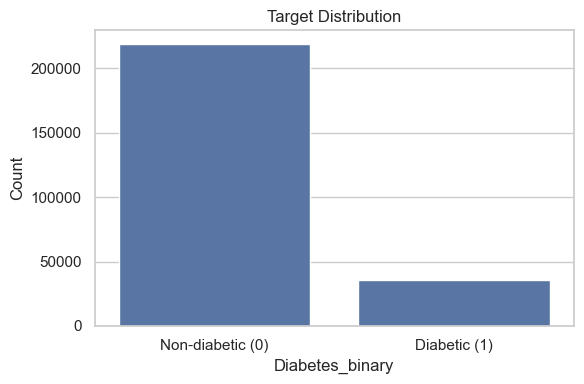

In [12]:
# Ve phan phoi target
target_counts = df["Diabetes_binary"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Target Distribution")
plt.xlabel("Diabetes_binary")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-diabetic (0)", "Diabetic (1)"])
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "target_distribution.png", dpi=150)
plt.show()

In [13]:
# Nhan xet mat can bang lop
non_diabetic_pct = (df["Diabetes_binary"] == 0).mean() * 100
diabetic_pct = (df["Diabetes_binary"] == 1).mean() * 100
print(f"\nKet luan:")
print(f"- Non-diabetic: {non_diabetic_pct:.1f}%")
print(f"- Diabetic: {diabetic_pct:.1f}%")
print(f"\nDataset mat can bang nghiem trong.")
print(f"Accuracy co the gay hieu lanh neu model chi du doan day so 0.")
print(f"Can uu tien ROC-AUC, F1-score, Recall cho lop diabetic.")


Ket luan:
- Non-diabetic: 86.1%
- Diabetic: 13.9%

Dataset mat can bang nghiem trong.
Accuracy co the gay hieu lanh neu model chi du doan day so 0.
Can uu tien ROC-AUC, F1-score, Recall cho lop diabetic.


### 6.2. Tần suất các biến categorical/binary/ordinal

In [14]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


Diabetes_binary:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

HighBP:
HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64

HighChol:
HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64

CholCheck:
CholCheck
0.0      9470
1.0    244210
Name: count, dtype: int64

BMI:
BMI
12.0      6
13.0     21
14.0     41
15.0    132
16.0    348
       ... 
91.0      1
92.0     32
95.0     12
96.0      1
98.0      7
Name: count, Length: 84, dtype: int64

Smoker:
Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64

Stroke:
Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64

HeartDiseaseorAttack:
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

PhysActivity:
PhysActivity
0.0     61760
1.0    191920
Name: count, dtype: int64

Fruits:
Fruits
0.0     92782
1.0    160898
Name: count, dtype: int64

Veggies:
Veggies
0.0     47839
1.0    205841
Name: count, dtype: int64

HvyAlcoholConsump:
HvyAlcoholConsump
0.0    23942

## 7. Correlation Heatmap

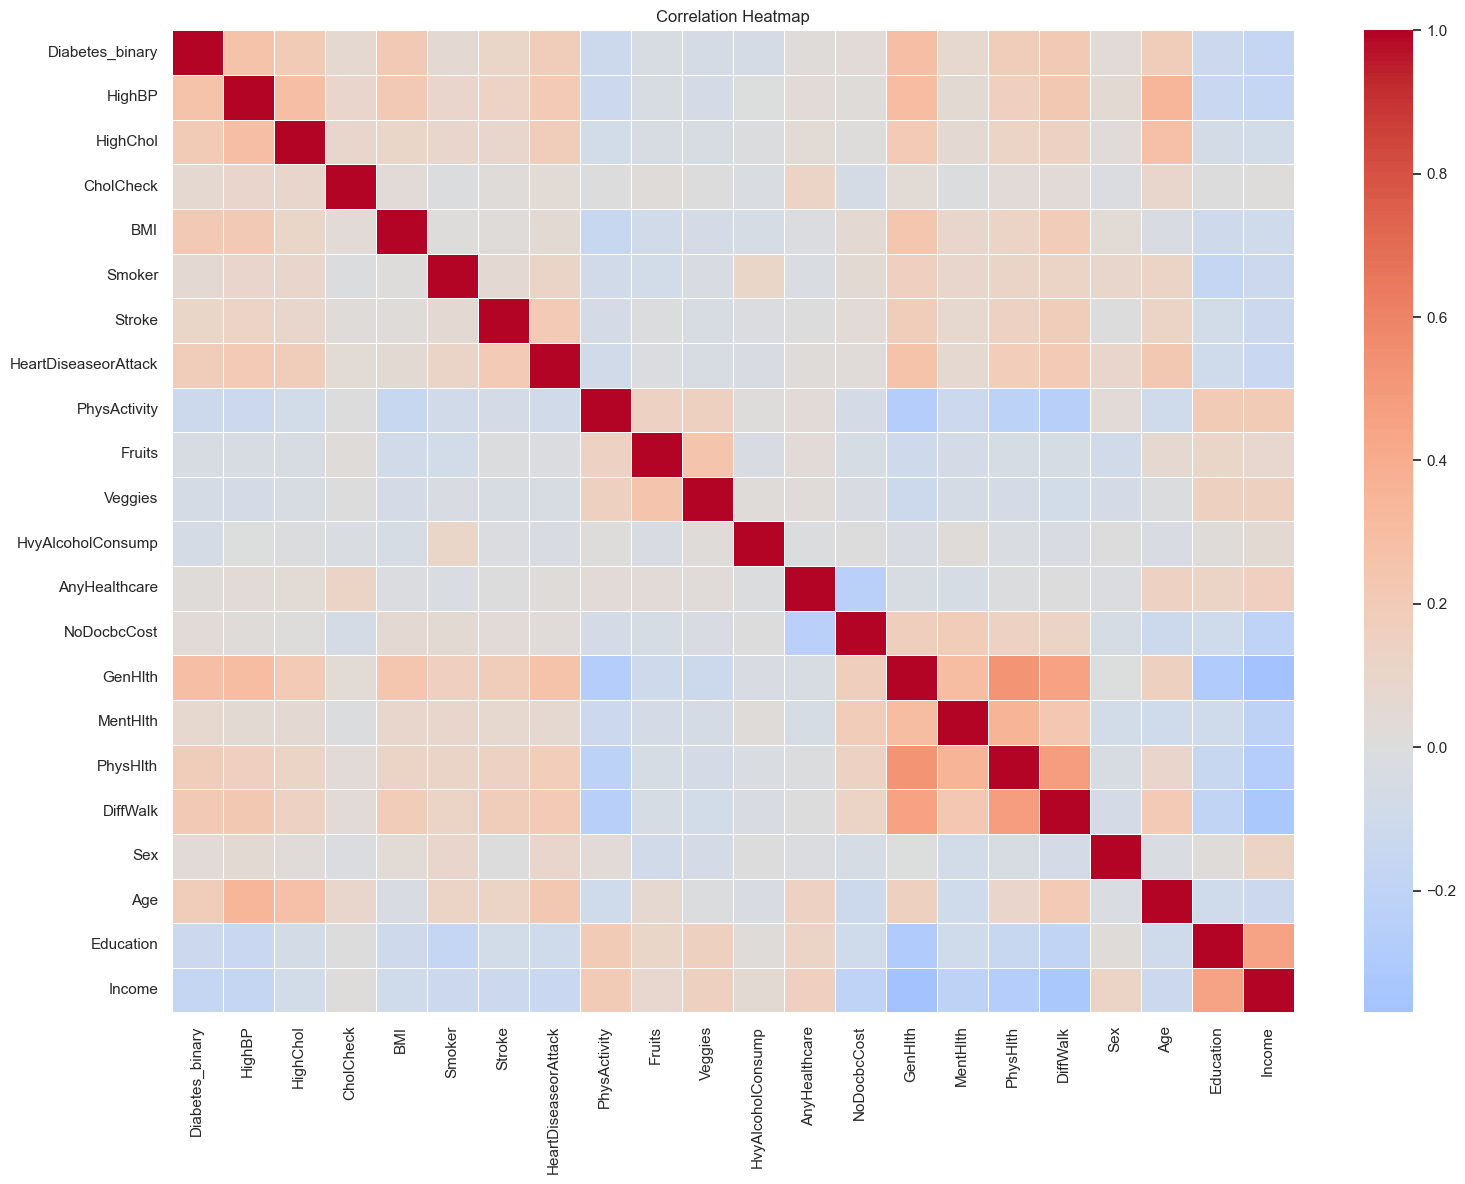

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "correlation_heatmap.png", dpi=150)
plt.show()

In [16]:
# Xem feature lien quan manh voi Diabetes_binary
target_corr = corr["Diabetes_binary"].sort_values(ascending=False)
print("Feature lien quan voi Diabetes_binary:")
print(target_corr)

Feature lien quan voi Diabetes_binary:
Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64


In [17]:
# Cac bien thuong co lien quan dang chu y
print("\nCac bien co tuong quan manh nhat voi target:")
print("- GenHlth: suc khoe tong quat")
print("- HighBP: huyet ap cao")
print("- BMI: chi so khoi co the")
print("- DiffWalk: kho di lai")
print("- HighChol: cholesteron cao")
print("- Age: tuoi")
print("- HeartDiseaseorAttack: benh tim")
print("- PhysHlth: suc khoe the chat")


Cac bien co tuong quan manh nhat voi target:
- GenHlth: suc khoe tong quat
- HighBP: huyet ap cao
- BMI: chi so khoi co the
- DiffWalk: kho di lai
- HighChol: cholesteron cao
- Age: tuoi
- HeartDiseaseorAttack: benh tim
- PhysHlth: suc khoe the chat


## 8. Histogram các biến liên tục/ordinal

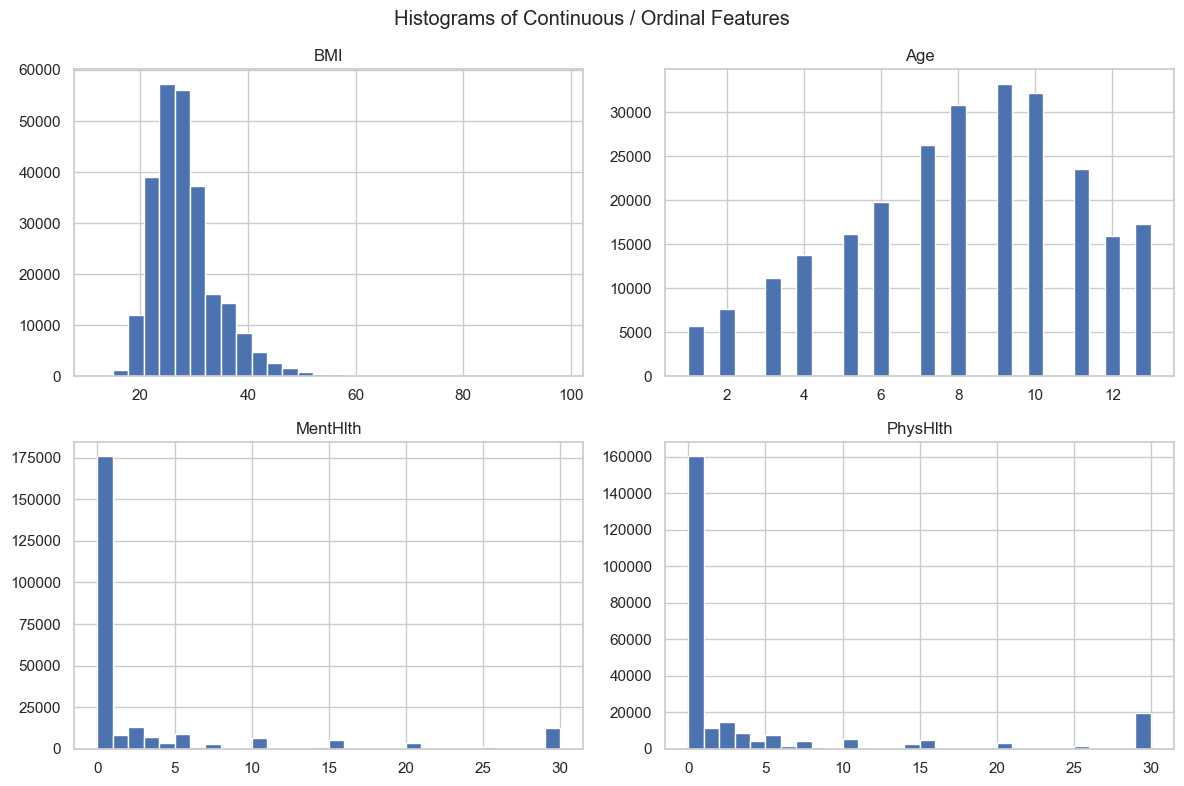

In [18]:
continuous_cols = ["BMI", "Age", "MentHlth", "PhysHlth"]

df[continuous_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Histograms of Continuous / Ordinal Features")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "continuous_histograms.png", dpi=150)
plt.show()

In [19]:
print("Nhan xet:")
print("- BMI phan phoi chuan, trung binh ~28")
print("- Age phan phoi deu cac nhom tuoi")
print("- MentHlth va PhysHlth lech phai, nhieu gia tri 0")

Nhan xet:
- BMI phan phoi chuan, trung binh ~28
- Age phan phoi deu cac nhom tuoi
- MentHlth va PhysHlth lech phai, nhieu gia tri 0


## 9. Boxplot theo Target

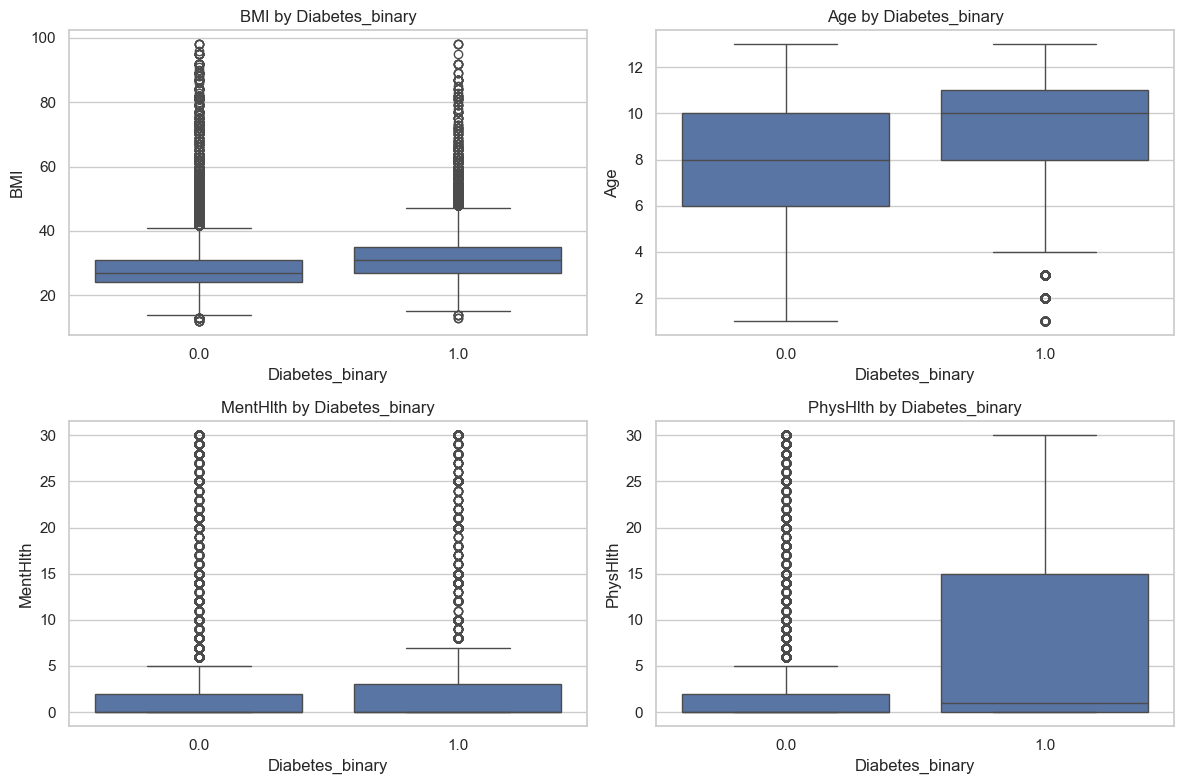

In [20]:
continuous_cols = ["BMI", "Age", "MentHlth", "PhysHlth"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    sns.boxplot(data=df, x="Diabetes_binary", y=col, ax=ax)
    ax.set_title(f"{col} by Diabetes_binary")
    ax.set_xlabel("Diabetes_binary")
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "boxplots.png", dpi=150)
plt.show()

In [21]:
print("Nhan xet:")
print("- Nhom diabetic thuong co BMI, Age, GenHlth, PhysHlth cao hon.")
print("- MentHlth co the lech phai vi nhieu nguoi co gia tri 0.")
print("- Mot so bien co outlier nhung khong can loai bo vi co the la ca that co y nghia du bao.")

Nhan xet:
- Nhom diabetic thuong co BMI, Age, GenHlth, PhysHlth cao hon.
- MentHlth co the lech phai vi nhieu nguoi co gia tri 0.
- Mot so bien co outlier nhung khong can loai bo vi co the la ca that co y nghia du bao.


## 10. Ket luan EDA

In [22]:
print("""
KET LUAN EDA:
=============
1. Du lieu sach: 253,680 dong, 22 cot, khong co missing values.
2. Target mat can bang: ~86% non-diabetic, ~14% diabetic.
3. Cac feature quan trong nhat: GenHlth, HighBP, BMI, DiffWalk, HighChol, Age.
4. BMI phan phoi chuan, cac bien khac chu yeu la binary/ordinal.
5. Khong can xu ly missing values, outlier giu nguyen.

KHUYEN NGHI:
- Dung ROC-AUC, F1, Recall lam metric chinh thay vi Accuracy.
- Can xu ly mat can bang bang class_weight hoac SMOTE.
- Nhung buoc tiep theo: Feature Engineering, chia train/test, chuan hoa, train model.
""")


KET LUAN EDA:
1. Du lieu sach: 253,680 dong, 22 cot, khong co missing values.
2. Target mat can bang: ~86% non-diabetic, ~14% diabetic.
3. Cac feature quan trong nhat: GenHlth, HighBP, BMI, DiffWalk, HighChol, Age.
4. BMI phan phoi chuan, cac bien khac chu yeu la binary/ordinal.
5. Khong can xu ly missing values, outlier giu nguyen.

KHUYEN NGHI:
- Dung ROC-AUC, F1, Recall lam metric chinh thay vi Accuracy.
- Can xu ly mat can bang bang class_weight hoac SMOTE.
- Nhung buoc tiep theo: Feature Engineering, chia train/test, chuan hoa, train model.

